In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os

## Load data

In [2]:
attributes_df = pd.read_csv("../data/raw/citywide/image_attributes_manifest.csv")

In [3]:
attributes_df.columns

Index(['image_path', 'file_exists', 'status', 'bytes', 'asset_id',
       'profile_id', 'profile_name', 'name', 'description', 'file_id',
       'filename', 'mime_type', 'service_date', 'historical_cost',
       'valuation_cost', 'is_disposed', 'updated', 'attr_Abutment Material',
       'attr_Adjacent Slope', 'attr_Area', 'attr_Bldg Number of Months in Use',
       'attr_Bridge Type', 'attr_Cross Slope Average', 'attr_Cross Slope Max',
       'attr_Decking Material', 'attr_Distance Between Benches',
       'attr_Fall Height', 'attr_GIS ID', 'attr_Has Edge Guard',
       'attr_Has Pedestrian Railing', 'attr_Has Pedestrian Walkway',
       'attr_Height', 'attr_Last Inspection by Qualified Professional',
       'attr_Length', 'attr_Load Capacity', 'attr_Manufacturer',
       'attr_Material (Frame, Tank, Body)',
       'attr_Next Inspection by Qualified Professional',
       'attr_Next Inspection by Staff', 'attr_Number of Steps',
       'attr_Obstacle Max Height', 'attr_PO2026 Agrmt Prio

### Keeping only necessary columns

In [4]:
attributes_df = attributes_df[[
    "image_path",
    "file_exists", 
    "asset_id", 
    "profile_id",
    "profile_name",
    "description",
    "file_id",
    "filename",
    "attr_Abutment Material",
    "attr_Bridge Type",
    "attr_Decking Material",
    "attr_Fall Height",
    "attr_Has Edge Guard",
    "attr_Has Pedestrian Railing",
    "attr_Length",
    "attr_Material (Frame, Tank, Body)",
    "attr_Number of Steps",
    "attr_Structure Material",
    "attr_Structure Position",
    "attr_Width"
]]

In [5]:
attributes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5562 entries, 0 to 5561
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   image_path                         5562 non-null   object 
 1   file_exists                        5562 non-null   bool   
 2   asset_id                           5562 non-null   int64  
 3   profile_id                         5562 non-null   int64  
 4   profile_name                       5562 non-null   object 
 5   description                        5138 non-null   object 
 6   file_id                            5562 non-null   int64  
 7   filename                           5562 non-null   object 
 8   attr_Abutment Material             2094 non-null   object 
 9   attr_Bridge Type                   2054 non-null   object 
 10  attr_Decking Material              4359 non-null   object 
 11  attr_Fall Height                   5499 non-null   float

In [6]:
attributes_df.describe(include='all')

,image_path,file_exists,asset_id,profile_id,profile_name,description,file_id,filename,attr_Abutment Material,attr_Bridge Type,attr_Decking Material,attr_Fall Height,attr_Has Edge Guard,attr_Has Pedestrian Railing,attr_Length,"attr_Material (Frame, Tank, Body)",attr_Number of Steps,attr_Structure Material,attr_Structure Position,attr_Width
count,5562,5562,5562.000000,5562.00000,5562,5138,5562.000000,5562,2094,2054,4359,5499.000000,3144,5439,5278,1958,1090.000000,4355,1321,4156
unique,5562,2,NaN,NaN,5,2709,NaN,5495,7,7,7,NaN,3,7,318,12,NaN,6,4,96
top,data/citywide/images/337/48117/86997__AST_EX_2...,True,NaN,NaN,Boardwalk < 1.2m High,"2"" rough cedar boardwalk on Cedar stringers",NaN,image.png,Timber,Beam,Timber,NaN,No,No railings,0,Timber/Wood,NaN,Timber,At-Grade,1
freq,1,5310,NaN,NaN,2096,108,NaN,17,830,1162,3198,NaN,2696,3662,918,989,NaN,2716,715,1215
mean,NaN,NaN,93610.365876,317.87073,NaN,NaN,52241.341244,NaN,NaN,NaN,NaN,-0.732606,NaN,NaN,NaN,NaN,-0.100000,NaN,NaN,NaN
std,NaN,NaN,22836.986596,61.30621,NaN,NaN,25182.601794,NaN,NaN,NaN,NaN,3.147281,NaN,NaN,NaN,NaN,5.286129,NaN,NaN,NaN
min,NaN,NaN,46340.000000,253.00000,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
25%,NaN,NaN,83988.500000,253.00000,NaN,NaN,27318.250000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
50%,NaN,NaN,94317.500000,337.00000,NaN,NaN,57405.500000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
75%,NaN,NaN,111476.000000,356.00000,NaN,NaN,72588.750000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN


In [7]:
print("Missing values:\n", attributes_df.isnull().sum())

Missing values:
 image_path                              0
file_exists                             0
asset_id                                0
profile_id                              0
profile_name                            0
description                           424
file_id                                 0
filename                                0
attr_Abutment Material               3468
attr_Bridge Type                     3508
attr_Decking Material                1203
attr_Fall Height                       63
attr_Has Edge Guard                  2418
attr_Has Pedestrian Railing           123
attr_Length                           284
attr_Material (Frame, Tank, Body)    3604
attr_Number of Steps                 4472
attr_Structure Material              1207
attr_Structure Position              4241
attr_Width                           1406
dtype: int64


In [8]:
# Number of files
attributes_df[attributes_df['file_exists'] == False]

,image_path,file_exists,asset_id,profile_id,profile_name,description,file_id,filename,attr_Abutment Material,attr_Bridge Type,attr_Decking Material,attr_Fall Height,attr_Has Edge Guard,attr_Has Pedestrian Railing,attr_Length,"attr_Material (Frame, Tank, Body)",attr_Number of Steps,attr_Structure Material,attr_Structure Position,attr_Width
515,data/citywide/images/337/88100/18816__AST_IM_2...,False,88100,337,Boardwalk < 1.2m High,NaN,18816,AST_IM_20210826_135759.jpeg,NaN,NaN,TBD,-1.0,No,No railings,0.00,NaN,NaN,TBD,NaN,0.00
516,data/citywide/images/337/88106/18838__AST_IM_2...,False,88106,337,Boardwalk < 1.2m High,NaN,18838,AST_IM_20210826_142533.jpeg,TBD,TBD,TBD,-1.0,NaN,No railings,0,NaN,NaN,TBD,NaN,0
517,data/citywide/images/337/85318/11784__AST_IM_2...,False,85318,337,Boardwalk < 1.2m High,Bridge in poor to okay condition. Crosses over...,11784,AST_IM_20210806_093045.jpeg,NaN,NaN,TBD,-1.0,No,No railings,0,NaN,NaN,TBD,NaN,0
518,data/citywide/images/337/88102/18818__AST_IM_2...,False,88102,337,Boardwalk < 1.2m High,pull out,18818,AST_IM_20210826_142039.jpeg,NaN,NaN,TBD,-1.0,No,No railings,0.00,NaN,NaN,TBD,NaN,0.00
519,data/citywide/images/337/88109/18833__AST_IM_2...,False,88109,337,Boardwalk < 1.2m High,Active creek,18833,AST_IM_20210826_142619.jpeg,TBD,TBD,TBD,-1.0,NaN,No railings,0,NaN,NaN,TBD,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4238,data/citywide/images/253/90844/24809__AST_IM_2...,False,90844,253,Trail Bridge,22ft long 2ft wide,24809,AST_IM_20210925_102537.jpeg,Timber,Beam,Timber,-1.0,NaN,No railings,6.7,NaN,NaN,Timber,NaN,0.6
4241,data/citywide/images/253/90844/24810__AST_IM_2...,False,90844,253,Trail Bridge,22ft long 2ft wide,24810,AST_IM_20210925_102405.jpeg,Timber,Beam,Timber,-1.0,NaN,No railings,6.7,NaN,NaN,Timber,NaN,0.6
4490,data/citywide/images/253/90844/24811__AST_IM_2...,False,90844,253,Trail Bridge,22ft long 2ft wide,24811,AST_IM_20210925_102427.jpeg,Timber,Beam,Timber,-1.0,NaN,No railings,6.7,NaN,NaN,Timber,NaN,0.6
4495,data/citywide/images/253/91253/25316__AST_IM_2...,False,91253,253,Trail Bridge,Bridge replaced by RST in 2025 - OUTSIDE OF PA...,25316,AST_IM_20211002_124841.jpeg,TBD,TBD,Timber,-1.0,NaN,TBD,13.7,NaN,NaN,TBD,NaN,0


### Assigning relevant attributes to asset categories

In [9]:
PROFILE_ATTRS = {
    "Boardwalk < 1.2m High": {
        "profile_id": 337,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width",
        ]
    },
    "Boardwalk > 1.2m High": {
        "profile_id": 573,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width",
        ]
    },
    "Stairs": {
        "profile_id": 356,
        "attrs": [
            "attr_Fall Height",
            "attr_Has Pedestrian Railing",
            "attr_Material (Frame, Tank, Body)",
            "attr_Number of Steps",
            "attr_Structure Position",
        ]
    },
    "Trail Bridge": {
        "profile_id": 253,
        "attrs": [
            "attr_Abutment Material",
            "attr_Bridge Type",
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width"
        ]
    },
    "Viewing Platform": {
        "profile_id": 359,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Structure Position",
            "attr_Width",
        ]
    }
}

### Possible values for each attribute

In [10]:
attr_cols = [c for c in attributes_df.columns if c.startswith("attr_")]

for col in attr_cols:
    if attributes_df[col].dtype == "object":
        print(f"\n{col}:\n  {sorted(attributes_df[col].dropna().unique().tolist())}")
    else:
        print(f"\n{col}:\n  min={attributes_df[col].min()}, values={sorted(attributes_df[col].dropna().unique().tolist())}")


attr_Abutment Material:
  ['Aluminum Sill Fill', 'Composite', 'Concrete', 'Gabions', 'Steel', 'TBD', 'Timber']

attr_Bridge Type:
  ['Beam', 'Fallen Tree', 'Other', 'Suspension', 'TBD', 'TBD | Beam', 'Truss']

attr_Decking Material:
  ['Aluminum', 'Asphalt', 'Composite', 'Concrete', 'Steel', 'TBD', 'Timber']

attr_Fall Height:
  min=-1.0, values=[-1.0, 0.0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.55, 0.6, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.55, 1.7, 1.85, 2.0, 2.4, 2.5, 2.6, 2.65, 3.0, 3.2, 3.9, 4.0, 5.5, 6.0, 9.0, 10.0, 18.0, 20.0, 125.0]

attr_Has Edge Guard:
  ['No', 'TBD', 'Yes']

attr_Has Pedestrian Railing:
  ['1 railing', '2 railings', 'No', 'No railings', 'TBD', 'TBD | No railings', 'TBD | Yes']

attr_Length:
  ['-1', '0', '0.00', '0.5', '1', '1.00', '1.38', '1.5', '1.50', '1.52', '1.7', '1.8', '1.83', '1.9', '10', '10.00', '10.2', '10.5', '10.668', '10.7', '100', '100.00', '1000', '104', '105', '106.70', '10m', '11', '11.00', '11.42', '11.7', '110', '112', '115', '118', '12', '12.0

### Creating function to remove invalid values for each attribute

In [11]:
MISSING_SENTINELS = {0.0, -1.0}  # numeric sentinels only, strings handled below

def is_valid(val):
    if pd.isna(val):
        return False
    if isinstance(val, str):
        val_stripped = val.strip()
        # Any value containing "TBD" is invalid
        if "TBD" in val_stripped.upper():
            return False
        # String representations of 0 or -1 (e.g. "0", "0.00", "-1", "-1.0")
        try:
            if float(val_stripped) in MISSING_SENTINELS:
                return False
        except ValueError:
            pass
    # Numeric 0 or -1
    if val in MISSING_SENTINELS:
        return False
    return True

In [12]:
# Directory for plot exports
output_dir = "../reports/report_images"
os.makedirs(output_dir, exist_ok=True)

### Valid attribute fill rate per asset category

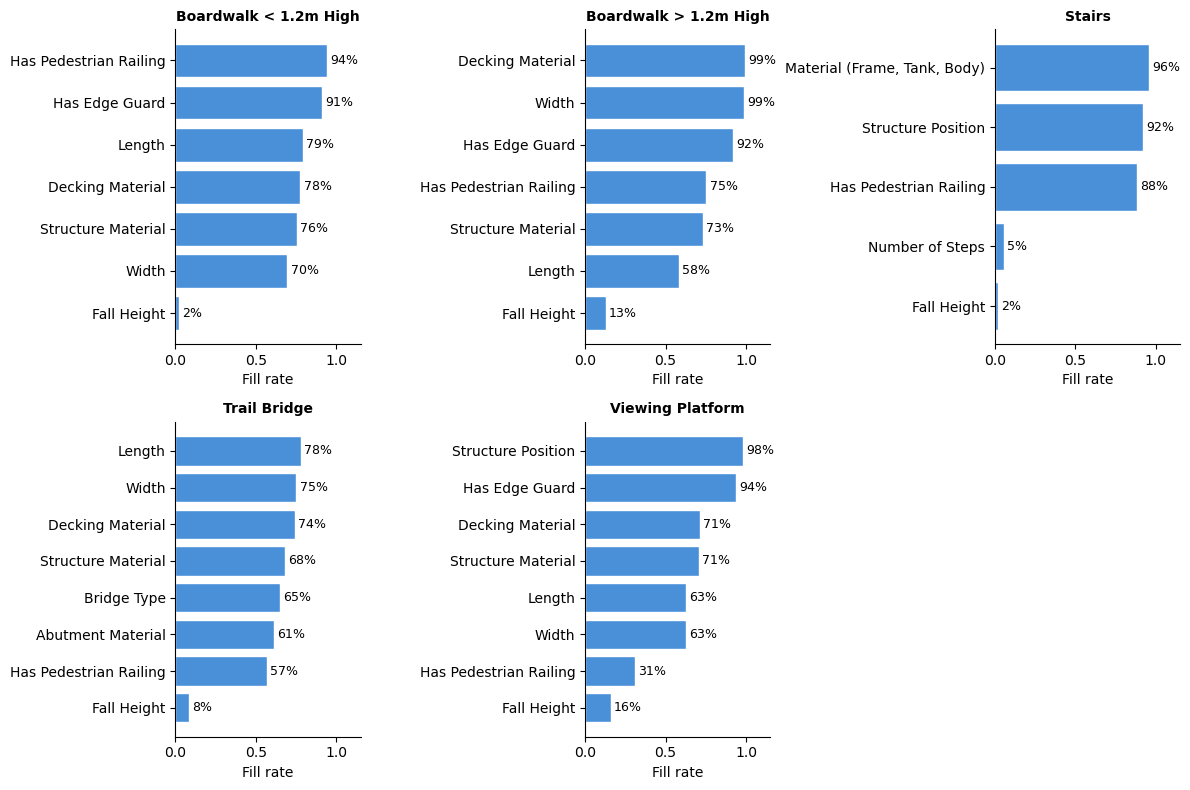

In [22]:
records = []

for category, info in PROFILE_ATTRS.items():
    subset = attributes_df[attributes_df["profile_name"] == category]
    for col in info["attrs"]:
        records.append({
            "category": category,
            "attr": col.replace("attr_", ""),
            "fill_rate": subset[col].apply(is_valid).mean(),
        })

fill_df = pd.DataFrame(records)

categories = list(PROFILE_ATTRS.keys())
n_cols = math.ceil(len(categories) / 2)
n_rows = math.ceil(len(categories) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, category in zip(axes, categories):
    data = fill_df[fill_df["category"] == category].sort_values("fill_rate")
    ax.barh(data["attr"], data["fill_rate"], color="#4a90d9", edgecolor="white")
    for val, patch in zip(data["fill_rate"], ax.patches):
        ax.text(patch.get_width() + 0.02, patch.get_y() + patch.get_height() / 2,
                f"{val:.0%}", va="center", fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_title(category, fontsize=10, fontweight="bold")
    ax.set_xlabel("Fill rate")
    ax.spines[["top", "right"]].set_visible(False)

# Remove any leftover axes
for ax in axes[len(categories):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "attribute_fill_rate.png"))
plt.show()

### Class distributions per attribute

In [17]:
attributes_df["attr_Length"] = attributes_df["attr_Length"].str.replace("m", "", regex=False).pipe(pd.to_numeric, errors="coerce")
attributes_df["attr_Width"] = attributes_df["attr_Width"].str.replace("m", "", regex=False).pipe(pd.to_numeric, errors="coerce")

In [18]:
num_attrs = ["attr_Fall Height", "attr_Number of Steps", "attr_Length", "attr_Width"]
cat_attrs = [col for col in attr_cols if col not in num_attrs]

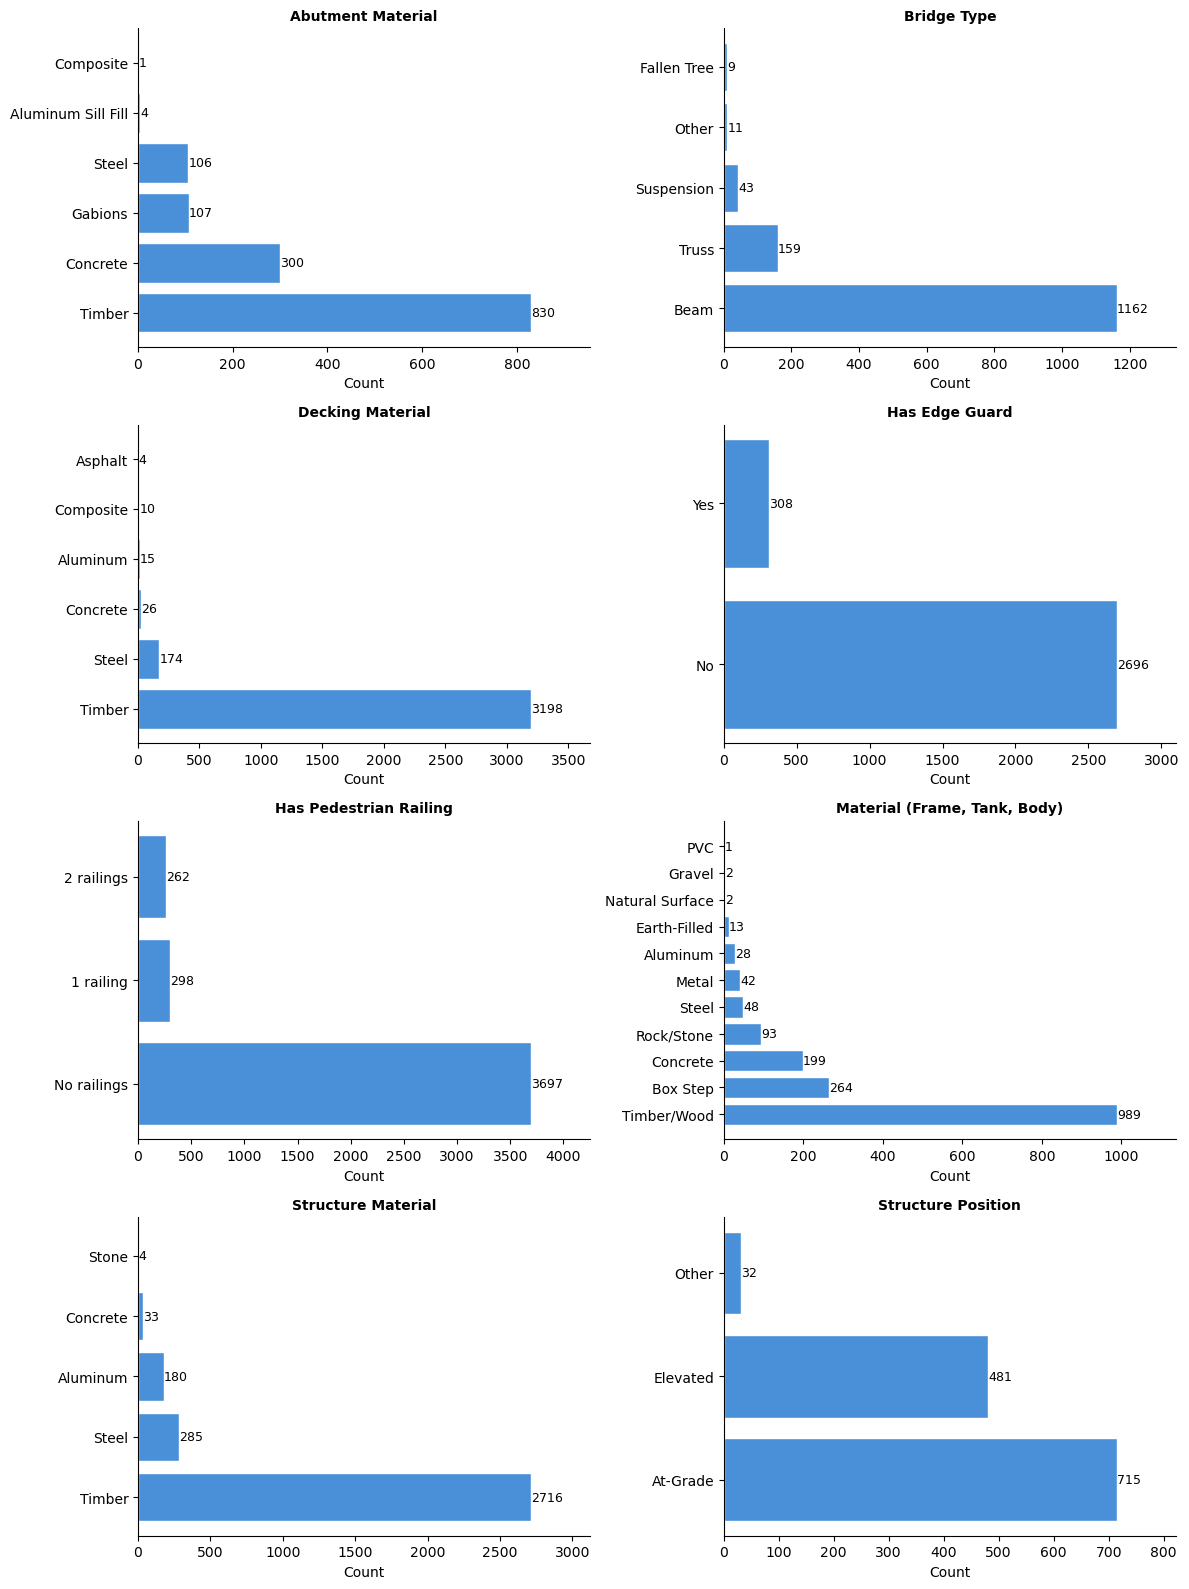

In [19]:
import math
import numpy as np

ncols = 2
nrows = math.ceil(len(cat_attrs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 4))
axes = np.array(axes).flatten().tolist()

# Define remappings for specific columns
remap = {
    "attr_Has Pedestrian Railing": {"No": "No railings"},
}

for ax, col in zip(axes, cat_attrs):
    valid_vals = attributes_df[col][attributes_df[col].apply(is_valid)]

    # Apply remapping if defined for this column
    if col in remap:
        valid_vals = valid_vals.replace(remap[col])

    counts = valid_vals.value_counts()

    if counts.empty:
        ax.set_visible(False)
        continue

    bars = ax.barh(counts.index.astype(str), counts.values, color="#4a90d9", edgecolor="white")

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=9)

    ax.set_title(col.replace("attr_", ""), fontsize=10, fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_xlim(0, counts.values.max() * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(cat_attrs):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "categorical_distributions.png"))
plt.show()

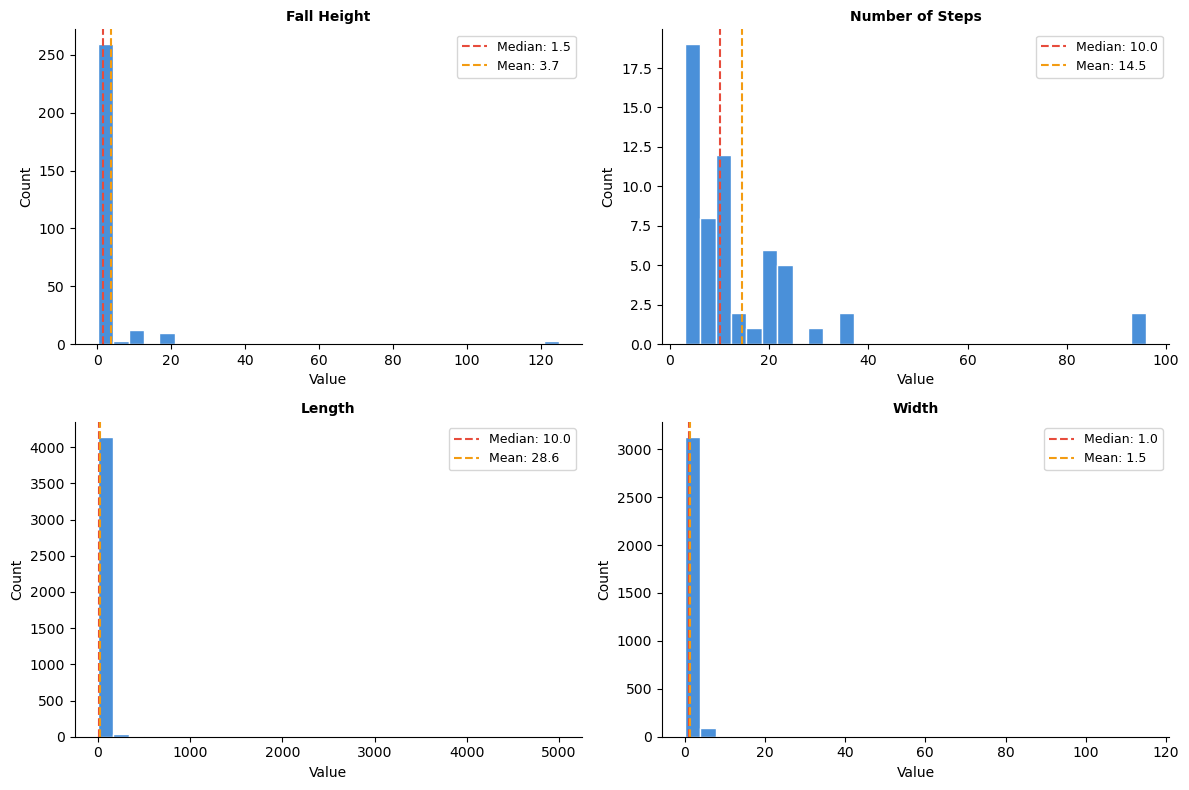

In [20]:
ncols = 2
nrows = math.ceil(len(num_attrs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 4))
axes = np.array(axes).flatten().tolist()

for ax, col in zip(axes, num_attrs):
    valid_vals = attributes_df[col][attributes_df[col].apply(is_valid)].dropna()

    ax.hist(valid_vals, bins=30, color="#4a90d9", edgecolor="white")
    ax.axvline(valid_vals.median(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Median: {valid_vals.median():.1f}")
    ax.axvline(valid_vals.mean(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mean: {valid_vals.mean():.1f}")
    ax.set_title(col.replace("attr_", ""), fontsize=10, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(num_attrs):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "numerical_distributions.png"))
plt.show()

## More Data Exploration/Cleaning

In [15]:
print("---COUNTS---")
print("Total images:", len(attributes_df))
print("Unique asset IDs:", attributes_df["asset_id"].nunique())
print("Avg images per asset:", len(attributes_df) / attributes_df["asset_id"].nunique())
print("Max images per asset:", attributes_df.groupby("asset_id")["filename"].count().max())
print("Min images per asset:", attributes_df.groupby("asset_id")["filename"].count().min())

---COUNTS---
Total images: 5562
Unique asset IDs: 3584
Avg images per asset: 1.5518973214285714
Max images per asset: 10
Min images per asset: 1


In [16]:
print("Unique asset IDs:", attributes_df["asset_id"].nunique())
print("Images per asset:")
print(attributes_df.groupby("asset_id")["filename"].count().describe())

Unique asset IDs: 3584
Images per asset:
count    3584.000000
mean        1.551897
std         1.175424
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: filename, dtype: float64


In [17]:
print("Assets with missing asset_id:", attributes_df["asset_id"].isna().sum())

Assets with missing asset_id: 0


In [18]:
no_asset = attributes_df[attributes_df["asset_id"].isna()]
print(f"Images with no asset ID: {len(no_asset)}")
print(no_asset["filename"].tolist())

Images with no asset ID: 0
[]


In [19]:
duplicates = attributes_df[attributes_df["filename"].duplicated(keep=False)]
print(f"Duplicate images: {len(duplicates)}")
print(duplicates[["filename", "asset_id", "profile_id"]])


Duplicate images: 101
                         filename  asset_id  profile_id
611                  IMG_0669.JPG     89710         337
894   AST_IM_20211013_102444.jpeg     92006         337
987                  IMG_0052.JPG     94269         337
1014                 IMG_0180.JPG     94300         337
1015                 IMG_0192.JPG     94303         337
...                           ...       ...         ...
5322   GetAttachmentThumbnail.jpg    128830         253
5324   GetAttachmentThumbnail.jpg    128831         253
5429                    image.png     57509         359
5430                    image.png     57509         359
5431                    image.png     57509         359

[101 rows x 3 columns]


In [20]:
#same image appears in multiple asset type folders
multi_folder = attributes_df.groupby("filename")["profile_id"].nunique()
print(f"\nImages in multiple folders: {(multi_folder > 1).sum()}")
print(multi_folder[multi_folder > 1])


Images in multiple folders: 10
filename
AST_IM_20211013_102444.jpeg    2
AST_IM_20220721_122330.jpeg    2
AST_IM_20220726_120244.jpeg    2
IMG_0052.JPG                   2
IMG_0180.JPG                   2
IMG_0192.JPG                   2
New stairs.jpg                 2
bridge1.jpg                    2
bridge3.jpg                    2
image.png                      3
Name: profile_id, dtype: int64


In [21]:
#from the above, i did manual checks of duplicates and they are not the same image
#more reliable column to check for duplicates is file_id. 
# sometimes there are same filename for images but different file id at the start, which signals they are different images
dup_by_id = attributes_df[attributes_df["file_id"].duplicated(keep=False)]
print(f"Duplicate file IDs: {len(dup_by_id)}")
print(dup_by_id[["filename", "asset_id", "file_id"]])

Duplicate file IDs: 0
Empty DataFrame
Columns: [filename, asset_id, file_id]
Index: []


In [22]:
#confirms no image has same file id + filename - no duplicate images present
dup_both = attributes_df[attributes_df.duplicated(subset=["file_id", "filename"], keep=False)]
print(f"Duplicates by file_id + filename: {len(dup_both)}")

Duplicates by file_id + filename: 0


In [23]:
#verifying we only have necessary cols
print("Current columns:")
print(attributes_df.columns.tolist())

Current columns:
['image_path', 'file_exists', 'status', 'bytes', 'asset_id', 'profile_id', 'profile_name', 'name', 'description', 'file_id', 'filename', 'mime_type', 'service_date', 'historical_cost', 'valuation_cost', 'is_disposed', 'updated', 'attr_Abutment Material', 'attr_Adjacent Slope', 'attr_Area', 'attr_Bldg Number of Months in Use', 'attr_Bridge Type', 'attr_Cross Slope Average', 'attr_Cross Slope Max', 'attr_Decking Material', 'attr_Distance Between Benches', 'attr_Fall Height', 'attr_GIS ID', 'attr_Has Edge Guard', 'attr_Has Pedestrian Railing', 'attr_Has Pedestrian Walkway', 'attr_Height', 'attr_Last Inspection by Qualified Professional', 'attr_Length', 'attr_Load Capacity', 'attr_Manufacturer', 'attr_Material (Frame, Tank, Body)', 'attr_Next Inspection by Qualified Professional', 'attr_Next Inspection by Staff', 'attr_Number of Steps', 'attr_Obstacle Max Height', 'attr_PO2026 Agrmt Priority', 'attr_Pipe Diameter', 'attr_Quantity of Shots', 'attr_Sign Mount Type', 'attr_St

### Standardizing Column names

In [24]:
#no spaces in col names, only underscores
attributes_df.columns = (
    attributes_df.columns
    .str.strip()          
    .str.lower()  
    .str.replace(" ", "_") 
    .str.replace("(", "") 
    .str.replace(")", "")
    .str.replace("/", "_")
    .str.replace("-", "_")
)

In [25]:
print(attributes_df.columns.tolist())

['image_path', 'file_exists', 'status', 'bytes', 'asset_id', 'profile_id', 'profile_name', 'name', 'description', 'file_id', 'filename', 'mime_type', 'service_date', 'historical_cost', 'valuation_cost', 'is_disposed', 'updated', 'attr_abutment_material', 'attr_adjacent_slope', 'attr_area', 'attr_bldg_number_of_months_in_use', 'attr_bridge_type', 'attr_cross_slope_average', 'attr_cross_slope_max', 'attr_decking_material', 'attr_distance_between_benches', 'attr_fall_height', 'attr_gis_id', 'attr_has_edge_guard', 'attr_has_pedestrian_railing', 'attr_has_pedestrian_walkway', 'attr_height', 'attr_last_inspection_by_qualified_professional', 'attr_length', 'attr_load_capacity', 'attr_manufacturer', 'attr_material_frame,_tank,_body', 'attr_next_inspection_by_qualified_professional', 'attr_next_inspection_by_staff', 'attr_number_of_steps', 'attr_obstacle_max_height', 'attr_po2026_agrmt_priority', 'attr_pipe_diameter', 'attr_quantity_of_shots', 'attr_sign_mount_type', 'attr_structure_material', 

In [26]:
# redefine which attributes apply to each asset type
ASSET_ATTRIBUTES = {
    "Boardwalk < 1.2m High": ["attr_decking_material", "attr_fall_height", "attr_has_edge_guard", 
                               "attr_has_pedestrian_railing", "attr_length", 
                               "attr_structure_material", "attr_width"],
    
    "Boardwalk > 1.2m High": ["attr_decking_material", "attr_fall_height", "attr_has_edge_guard",
                               "attr_has_pedestrian_railing", "attr_length",
                               "attr_structure_material", "attr_width"],
    
    "Stairs": ["attr_fall_height", "attr_has_pedestrian_railing", 
               "attr_material_frame,_tank,_body", "attr_number_of_steps",
               "attr_structure_position"],
    
    "Trail Bridge": ["attr_abutment_material", "attr_bridge_type", "attr_decking_material",
                     "attr_fall_height", "attr_has_pedestrian_railing", "attr_length",
                     "attr_structure_material", "attr_width"],
    
    "Viewing Platform": ["attr_decking_material", "attr_fall_height", "attr_has_edge_guard",
                          "attr_has_pedestrian_railing", "attr_length",
                          "attr_structure_material", "attr_structure_position", "attr_width"]
}

# inspect all value distributions per asset type
for asset_type, cols in ASSET_ATTRIBUTES.items():
    print(f"\n{'='*60}")
    print(f"ASSET TYPE: {asset_type}")
    subset = attributes_df[attributes_df["profile_name"] == asset_type]
    print(f"Total rows: {len(subset)}")
    
    for col in cols:
        if col in attributes_df.columns:
            n_unique = subset[col].nunique()
            print(f"\n  {col} — {n_unique} unique values")
            
            if n_unique <= 30:
                print(subset[col].value_counts(dropna=False).to_string())
            else:
                print(subset[col].describe()[["count", "min", "mean", "max"]])


ASSET TYPE: Boardwalk < 1.2m High
Total rows: 2096

  attr_decking_material — 5 unique values
attr_decking_material
Timber       1578
TBD           373
NaN            95
Steel          48
Aluminum        1
Composite       1

  attr_fall_height — 12 unique values
attr_fall_height
-1.00    1991
 0.00      46
 0.50      13
 NaN        9
 1.00       8
 1.50       6
 0.10       6
 0.20       6
 0.25       3
 0.60       2
 0.30       2
 0.40       2
 1.40       2

  attr_has_edge_guard — 3 unique values
attr_has_edge_guard
No     1861
NaN     180
Yes      42
TBD      13

  attr_has_pedestrian_railing — 4 unique values
attr_has_pedestrian_railing
No railings    1931
NaN              79
TBD              45
No               32
1 railing         9

  attr_length — 166 unique values
count    1913.000000
min        -1.000000
mean       41.660879
max      5000.000000
Name: attr_length, dtype: float64

  attr_structure_material — 5 unique values
attr_structure_material
Timber      1561
TBD         

In [27]:
#manually inspecting numerical outliers (unusually large numbers for fall height?)
fall_height_outliers = attributes_df[attributes_df["attr_fall_height"] > 10][
    ["asset_id", "profile_id", "filename", "profile_name", "attr_fall_height"]
]
print("Fall height outliers:")
print(fall_height_outliers)

length_outliers = attributes_df[attributes_df["attr_length"] > 500][
    ["asset_id", "profile_id", "filename", "profile_name", "attr_length"]
]
print("\nLength outliers:")
print(length_outliers)

Fall height outliers:
      asset_id  profile_id                     filename      profile_name  \
3500     51798         253  AST_EX_20210719_112242.jpeg      Trail Bridge   
3501     51798         253  AST_EX_20241128_121359.jpeg      Trail Bridge   
3502     51798         253  AST_EX_20241128_121253.jpeg      Trail Bridge   
3503     51798         253  AST_EX_20241128_121213.jpeg      Trail Bridge   
3504     51798         253  AST_EX_20241128_121243.jpeg      Trail Bridge   
3505     51798         253  AST_EX_20241128_121412.jpeg      Trail Bridge   
3507     51798         253  AST_EX_20241128_121149.jpeg      Trail Bridge   
5434     58829         359  AST_EX_20231214_122401.jpeg  Viewing Platform   
5435     58829         359  AST_EX_20241028_154517.jpeg  Viewing Platform   
5436     58829         359  AST_EX_20250707_091202.jpeg  Viewing Platform   
5482     74894         359  AST_EX_20231214_121609.jpeg  Viewing Platform   
5483     74894         359  AST_EX_20241028_153355.jpe

### Standardizing Nan Values

In [28]:
#using already defined is_valid function from EDA

attribute_cols = [col for col in attributes_df.columns if col.startswith("attr_")]

for col in attribute_cols:
    attributes_df[col] = attributes_df[col].apply(
        lambda x: x if is_valid(x) else np.nan
    )

print("After cleaning - NaN counts per attribute:")
print(attributes_df[attribute_cols].isna().sum())

After cleaning - NaN counts per attribute:
attr_abutment_material                            4214
attr_adjacent_slope                               5545
attr_area                                         5377
attr_bldg_number_of_months_in_use                 5562
attr_bridge_type                                  4178
attr_cross_slope_average                          5561
attr_cross_slope_max                              5561
attr_decking_material                             2135
attr_distance_between_benches                     5561
attr_fall_height                                  5275
attr_gis_id                                          8
attr_has_edge_guard                               2558
attr_has_pedestrian_railing                       1305
attr_has_pedestrian_walkway                       5528
attr_height                                       3339
attr_last_inspection_by_qualified_professional    2192
attr_length                                       1343
attr_load_capacity    

In [29]:
# standardizing values of has_pedestrian_railing attribute
railing_mapping = {
    "No": "No railings",
    "No railings": "No railings",
    "1 railing": "1 railing",
    "2 railings": "2 railings"
}
attributes_df["attr_has_pedestrian_railing"] = (
    attributes_df["attr_has_pedestrian_railing"].map(railing_mapping)
)

print(attributes_df["attr_has_pedestrian_railing"].value_counts(dropna=False))

attr_has_pedestrian_railing
No railings    3697
NaN            1305
1 railing       298
2 railings      262
Name: count, dtype: int64


In [30]:
#checking values after standardizing nan values across columns

attr_cols = [c for c in attributes_df.columns if c.startswith("attr_")]

for col in attr_cols:
    if attributes_df[col].dtype == "object":
        print(f"\n{col}:\n  {sorted(attributes_df[col].dropna().unique().tolist())}")
    else:
        print(f"\n{col}:\n  min={attributes_df[col].min()}, values={sorted(attributes_df[col].dropna().unique().tolist())}")


attr_abutment_material:
  ['Aluminum Sill Fill', 'Composite', 'Concrete', 'Gabions', 'Steel', 'Timber']

attr_adjacent_slope:
  ['< 22.5°', '> 22.5°']

attr_area:
  min=10.0, values=[10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 28.0, 30.0, 32.0, 36.0, 40.0, 44.0, 45.0, 60.0]

attr_bldg_number_of_months_in_use:
  min=nan, values=[]

attr_bridge_type:
  ['Beam', 'Fallen Tree', 'Other', 'Suspension', 'Truss']

attr_cross_slope_average:
  min=1.0, values=[1.0]

attr_cross_slope_max:
  min=1.0, values=[1.0]

attr_decking_material:
  ['Aluminum', 'Asphalt', 'Composite', 'Concrete', 'Steel', 'Timber']

attr_distance_between_benches:
  min=1.0, values=[1.0]

attr_fall_height:
  min=0.1, values=[0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.55, 0.6, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.55, 1.7, 1.85, 2.0, 2.4, 2.5, 2.6, 2.65, 3.0, 3.2, 3.9, 4.0, 5.5, 6.0, 9.0, 10.0, 18.0, 20.0, 125.0]

attr_gis_id:
  ['61732', '61734', '61735', '61736', '61737', '61742', 'Bridge.126740', 'Structure.126292', 'Structures.

### Filtering for length measured by staff only - copilot values will not be used as ground truth for training purposes

In [33]:
old_attachments = pd.read_excel("../data/raw/citywide/Capstone_Assets_Attributes_FileAttachments_recent.xlsx", sheet_name="attachments")

print("Old:", len(old_attachments))
print("New CSV:", len(attributes_df))

old_filenames = set(old_attachments["File Name"].tolist())
new_filenames = set(attributes_df["filename"].tolist())


extra = attributes_df[~attributes_df["filename"].isin(old_filenames)]
print(f"New rows: {len(extra)}")
print(extra[["asset_id", "filename", "profile_name"]])

Old: 5525
New CSV: 5562
New rows: 102
      asset_id                     filename           profile_name
146      65430  AST_EX_20210916_163423.jpeg  Boardwalk < 1.2m High
164      83121  AST_IM_20210708_113124.jpeg  Boardwalk < 1.2m High
165      83121  AST_IM_20210708_113117.jpeg  Boardwalk < 1.2m High
444      86329  AST_IM_20210812_123228.jpeg  Boardwalk < 1.2m High
446      86329  AST_EX_20251019_143317.jpeg  Boardwalk < 1.2m High
...        ...                          ...                    ...
5440     60962  AST_EX_20220407_152337.jpeg       Viewing Platform
5441     60962  AST_EX_20220407_152320.jpeg       Viewing Platform
5442     60962  AST_EX_20220407_152300.jpeg       Viewing Platform
5445     61424  AST_EX_20241024_121703.jpeg       Viewing Platform
5457     66956       MI_20210803_125548.jpg       Viewing Platform

[102 rows x 3 columns]


In [34]:
missing_from_new = old_attachments[~old_attachments["File Name"].isin(attributes_df["filename"])]
print(f"Rows in old but not in new CSV: {len(missing_from_new)}")
print(missing_from_new[["Asset ID", "File Name"]].head(20))

Rows in old but not in new CSV: 69
      Asset ID                    File Name
118     102345  AST_IM_20220615_114856.jpeg
162      61577      besa-river-bridge-2.JPG
163      61577        besa-river-bridge.JPG
791      92432  AST_EX_20250130_165340.jpeg
844      93364  AST_IM_20211104_110012.jpeg
931     102532  AST_IM_20220616_102900.jpeg
1323     55472  AST_EX_20250402_105349.jpeg
1324     55472  AST_EX_20250402_105356.jpeg
1360     61501  AST_EX_20210711_092946.jpeg
1361     61501  AST_EX_20210711_093306.jpeg
1362     61501  AST_EX_20210711_093315.jpeg
1852     54329          20210529_120011.jpg
1853     54329          20210529_115955.jpg
1854     54329          20210529_120001.jpg
1855     54329          20210529_115758.jpg
1856     54329          20210529_115840.jpg
1857     54329          20210529_115742.jpg
1858     54329          20210529_115814.jpg
1859     54329          20210529_115833.jpg
1924     56467  AST_EX_20250117_131710.jpeg


102 rows/images that are in new attributes file, that are not in old excel file provided by Hilary. 105 in old that are not in new.

In [35]:
dupes = old_attachments[old_attachments["File Name"].duplicated(keep=False)]
print(dupes[["File Name", "Asset ID", "Length measured by staff"]].sort_values("File Name"))

                        File Name  Asset ID  Length measured by staff
4703  AST_EX_20230415_114331.jpeg    116621                      True
4707  AST_EX_20230415_114331.jpeg    116621                      True
4706  AST_EX_20230415_114331.jpeg    116621                      True
4705  AST_EX_20230415_114331.jpeg    116621                      True
4704  AST_EX_20230415_114331.jpeg    116621                      True
...                           ...       ...                       ...
2130                    image.png     63066                      True
2504                    image.png     95730                      True
2505                    image.png     95730                      True
1982                    image.png     57509                     False
1984                    image.png     57509                     False

[92 rows x 3 columns]


In [36]:
old_attachments_slim = (old_attachments[["File Name", "Asset ID", "Length measured by staff"]]
    .drop_duplicates(subset=["File Name", "Asset ID"], keep="first") 
    .rename(columns={"File Name": "filename", "Asset ID": "asset_id"})
)

print(f"Before: {len(old_attachments)}")
print(f"After: {len(old_attachments_slim)}")

Before: 5525
After: 5487


In [37]:
attributes_df = attributes_df.merge(
    old_attachments_slim[["filename", "asset_id", "Length measured by staff"]],
    on=["filename", "asset_id"],
    how="left"
)

print(f"Shape after merge: {attributes_df.shape}")
print("\nLength measured by staff counts:")
print(attributes_df["Length measured by staff"].value_counts(dropna=False))

Shape after merge: (5562, 62)

Length measured by staff counts:
Length measured by staff
True     3082
False    2373
NaN       107
Name: count, dtype: int64


In [38]:
# only trust length values where measured by staff
attributes_df.loc[attributes_df["Length measured by staff"] != True, "attr_length"] = np.nan

print("Length values after filtering:")
print(attributes_df["attr_length"].notna().sum(), "valid length values")

Length values after filtering:
3082 valid length values


### Binning numerical attributes

From BCParks professional inspection documentation, assets with fall height > 1.2 is when assets need to be inspected by field engineers every 5 years.

In [39]:
#checking numerical dists by asset type (same as EDA figure above)
for col in ["attr_length", "attr_width", "attr_fall_height", "attr_number_of_steps"]:
    if col in attributes_df.columns:
        print(f"\n{col}:")
        print(attributes_df.groupby("profile_name")[col].describe()[["min", "mean", "max", "count"]])


attr_length:
                       min       mean     max   count
profile_name                                         
Boardwalk < 1.2m High  0.5  47.783857  5000.0  1644.0
Boardwalk > 1.2m High  1.0  18.915319   100.0    81.0
Stairs                 2.0  10.437500   115.0    48.0
Trail Bridge           1.0  12.506963   240.0  1284.0
Viewing Platform       1.8  19.632000    30.0    25.0

attr_width:
                       min      mean     max   count
profile_name                                        
Boardwalk < 1.2m High  0.2  1.172899   42.00  1457.0
Boardwalk > 1.2m High  0.3  1.144443    3.00   148.0
Stairs                 0.6  0.817500    1.07     4.0
Trail Bridge           0.1  1.503602  115.00  1499.0
Viewing Platform       1.0  4.070699   13.00   143.0

attr_fall_height:
                        min       mean    max  count
profile_name                                        
Boardwalk < 1.2m High  0.10   0.629000    1.5   50.0
Boardwalk > 1.2m High  0.50   1.357895    2.0 

Because of the different value ranges across attributes AND assets, bins will be attribute and asset specific for now.

In [40]:
#function to generate discretized length by asset 

def bin_length(row):
    val = row["attr_length"]
    asset = row["profile_name"]
    
    if pd.isna(val):
        return np.nan
    
    if asset == "Boardwalk < 1.2m High":
        # range 0.5-5000, mean 48
        if val < 20:        return "short (<20m)"
        elif val < 100:     return "medium (20-100m)"
        else:               return "long (>100m)"
    
    elif asset == "Boardwalk > 1.2m High":
        # range 1-100, mean 19
        if val < 10:        return "short (<10m)"
        elif val < 30:      return "medium (10-30m)"
        else:               return "long (>30m)"
    
    elif asset == "Stairs":
        # range 2-115, mean 10
        if val < 5:         return "short (<5m)"
        elif val < 20:      return "medium (5-20m)"
        else:               return "long (>20m)"
    
    elif asset == "Trail Bridge":
        # range 1-240, mean 12.5
        if val < 6:         return "short (<6m)"
        elif val < 20:      return "medium (6-20m)"
        else:               return "long (>20m)"
    
    elif asset == "Viewing Platform":
        # range 1.8-30, mean 19.6
        if val < 10:        return "small (<10m)"
        elif val < 20:      return "medium (10-20m)"
        else:               return "large (>20m)"
    
    return np.nan

attributes_df["length_bin"] = attributes_df.apply(bin_length, axis=1)

In [41]:
# function to create discretized widths, specific to each asset based on above stats

def bin_width(row):
    val = row["attr_width"]
    asset = row["profile_name"]
    
    if pd.isna(val):
        return np.nan
    
    if asset == "Viewing Platform":
        # range 1-13, mean 4
        if val < 3:         return "narrow (<3m)"
        elif val < 7:       return "medium (3-7m)"
        else:               return "wide (>7m)"
    
    elif asset == "Stairs":
        # range 0.6-1.07, very narrow range
        if val < 0.8:       return "narrow (<0.8m)"
        else:               return "standard (>=0.8m)"
    
    else:
        # boardwalks and trail bridge - range 0.1-3 (excluding outliers)
        if val < 0.9:       return "narrow (<0.9m)"
        elif val < 1.5:     return "standard (0.9-1.5m)"
        else:               return "wide (>1.5m)"
    
    return np.nan

attributes_df["width_bin"] = attributes_df.apply(bin_width, axis=1)

In [42]:
# fall height bins 

def bin_fall_height(row):
    val = row["attr_fall_height"]
    asset = row["profile_name"]
    
    if pd.isna(val):
        return np.nan
    
    if asset == "Viewing Platform":
        # range 0.25-125, mean 13 — very wide range
        if val < 1.2:         return "low (<1.2m)"
        elif val < 15:      return "medium (1.2-15m)"
        else:               return "high (>15m)"
    
    elif asset == "Trail Bridge":
        # range 0.2-18, mean 3.2
        if val < 1.2:         return "low (<1.2m)"
        elif val < 5:       return "medium (1.2-5m)"
        else:               return "high (>5m)"
    
    else:
        # boardwalks and stairs - range 0.1-2, mean 0.6-1.4
        if val < 0.5:       return "low (<0.5m)"
        elif val < 1.2:     return "medium (0.5-1.2m)"
        else:               return "high (>1.2m)"
    
    return np.nan

attributes_df["fall_height_bin"] = attributes_df.apply(bin_fall_height, axis=1)

In [43]:
#number of steps : stairs only 

def bin_steps(row):
    val = row["attr_number_of_steps"]
    asset = row["profile_name"]
    
    if pd.isna(val) or asset != "Stairs":
        return np.nan
    
    if val < 10:        return "few (<10)"
    elif val < 20:      return "medium (10-20)"
    else:               return "many (>20)"

attributes_df["steps_bin"] = attributes_df.apply(bin_steps, axis=1)

In [44]:
#verifying bins 

for col in ["length_bin", "width_bin", "fall_height_bin", "steps_bin"]:
    print(f"\n{col}:")
    print(attributes_df.groupby("profile_name")[col].value_counts(dropna=False))


length_bin:
profile_name           length_bin      
Boardwalk < 1.2m High  short (<20m)        1002
                       medium (20-100m)     489
                       NaN                  452
                       long (>100m)         153
Boardwalk > 1.2m High  NaN                   69
                       short (<10m)          40
                       medium (10-30m)       25
                       long (>30m)           16
Stairs                 NaN                 1045
                       short (<5m)           22
                       medium (5-20m)        21
                       long (>20m)            5
Trail Bridge           NaN                  711
                       medium (6-20m)       673
                       short (<6m)          428
                       long (>20m)          183
Viewing Platform       NaN                  203
                       large (>20m)          15
                       medium (10-20m)        6
                       small (<10m)

In [45]:
#saving master csv. binned attributes added as separate cols, they are not replacing original numerical attribute cols
attributes_df.to_csv("../data/processed/master_dataset.csv", index=False)
print(f"Saved master: {attributes_df.shape}")

Saved master: (5562, 66)


### Saving Dataframes for each Asset Type

In [46]:
base_cols = ["asset_id", "filename", "file_id", "profile_name", "image_path"]

# defining binned cols for each asset type
bin_cols = {
    "Boardwalk < 1.2m High": ["length_bin", "width_bin", "fall_height_bin"],
    "Boardwalk > 1.2m High": ["length_bin", "width_bin", "fall_height_bin"],
    "Stairs": ["fall_height_bin", "steps_bin"],
    "Trail Bridge": ["length_bin", "width_bin", "fall_height_bin"],
    "Viewing Platform": ["length_bin", "width_bin", "fall_height_bin"]
}

In [47]:
asset_dfs = {}
for asset_type, attr_cols in ASSET_ATTRIBUTES.items():
    cols = base_cols + attr_cols + bin_cols[asset_type]
    cols_available = [c for c in cols if c in attributes_df.columns]
    
    df = attributes_df[attributes_df["profile_name"] == asset_type][cols_available].copy()
    asset_dfs[asset_type] = df
    
    filename = (asset_type.lower()
                .replace(" ", "_")
                .replace("<", "lt")
                .replace(">", "gt")
                .replace(".", ""))
    
    df.to_csv(f"../data/processed/{filename}.csv", index=False)
    print(f"{asset_type}: {len(df)} rows, {df['asset_id'].nunique()} assets")

Boardwalk < 1.2m High: 2096 rows, 1645 assets
Boardwalk > 1.2m High: 150 rows, 84 assets
Stairs: 1093 rows, 691 assets
Trail Bridge: 1995 rows, 1065 assets
Viewing Platform: 228 rows, 99 assets


## Handling outliers in numerical attributes

In [77]:
data = pd.read_csv("../data/processed/master_dataset.csv")
print(f"Loaded: {data.shape}")
print(data.columns.tolist())

Loaded: (5562, 25)
['image_path', 'file_exists', 'asset_id', 'profile_id', 'profile_name', 'description', 'file_id', 'filename', 'attr_abutment_material', 'attr_bridge_type', 'attr_decking_material', 'attr_fall_height', 'attr_has_edge_guard', 'attr_has_pedestrian_railing', 'attr_length', 'attr_material_frame,_tank,_body', 'attr_number_of_steps', 'attr_structure_material', 'attr_structure_position', 'attr_width', 'Length measured by staff', 'length_bin', 'width_bin', 'fall_height_bin', 'steps_bin']


In [78]:
num_cols = ["attr_length", "attr_width", "attr_fall_height", "attr_number_of_steps"]

for col in num_cols:
    if col in data.columns:
        print(f"\n{col} stats per asset type:")
        print(data.groupby("profile_name")[col].describe()[["count", "min", "mean", "max"]])


attr_length stats per asset type:
                        count  min       mean     max
profile_name                                         
Boardwalk < 1.2m High  1643.0  0.5  44.769726  2600.0
Boardwalk > 1.2m High    81.0  1.0  18.915319   100.0
Stairs                   47.0  2.0   8.212766    49.0
Trail Bridge           1284.0  1.0  12.506963   240.0
Viewing Platform         25.0  1.8  19.632000    30.0

attr_width stats per asset type:
                        count  min      mean    max
profile_name                                       
Boardwalk < 1.2m High  1457.0  0.2  1.172899  42.00
Boardwalk > 1.2m High   148.0  0.3  1.144443   3.00
Stairs                    4.0  0.6  0.817500   1.07
Trail Bridge           1498.0  0.1  1.427837  20.00
Viewing Platform        143.0  1.0  4.070699  13.00

attr_fall_height stats per asset type:
                       count   min      mean   max
profile_name                                      
Boardwalk < 1.2m High   50.0  0.10  0.629000   

In [79]:
print("Viewing Platform fall heights:")
print(data[data["profile_name"] == "Viewing Platform"][
    ["asset_id", "filename", "attr_fall_height"]
].sort_values("attr_fall_height", ascending=False).head(20))

print("\nTrail Bridge fall heights > 10m:")
print(data[
    (data["profile_name"] == "Trail Bridge") & 
    (data["attr_fall_height"] > 10)
][["asset_id", "filename", "attr_fall_height"]])

Viewing Platform fall heights:
      asset_id                     filename  attr_fall_height
5484     74894  AST_EX_20250707_084834.jpeg              20.0
5482     74894  AST_EX_20231214_121609.jpeg              20.0
5483     74894  AST_EX_20241028_153355.jpeg              20.0
5525    100150  AST_EX_20250107_134031.jpeg               1.5
5518    100150  AST_IM_20220529_143232.jpeg               1.5
5517    100150  AST_IM_20220529_143250.jpeg               1.5
5522    100150  AST_EX_20250107_134311.jpeg               1.5
5523    100150  AST_EX_20250107_133932.jpeg               1.5
5524    100150  AST_EX_20250107_133914.jpeg               1.5
5519    100150  AST_EX_20250107_134049.jpeg               1.5
5520    100150  AST_EX_20250107_134124.jpeg               1.5
5521    100150  AST_EX_20250107_134151.jpeg               1.5
5437     59089  AST_EX_20220214_104436.jpeg               1.2
5551    123598               1000020657.jpg               1.0
5552    123598               1000020659

In [80]:
data.loc[
    (data["asset_id"] == 58829) & (data["attr_fall_height"] == 125.0), 
    "attr_fall_height"
] = np.nan

data.loc[data["asset_id"] == 58829, "fall_height_bin"] = np.nan

In [81]:
print("\nBoardwalk length > 1000m:")
print(data[
    (data["profile_name"] == "Boardwalk < 1.2m High") & 
    (data["attr_length"] > 1000)
][["asset_id", "filename", "attr_length"]])

print("\nStairs length > 50m:")
print(data[
    (data["profile_name"] == "Stairs") & 
    (data["attr_length"] > 50)
][["asset_id", "filename", "attr_length"]])

print("\nTrail Bridge width > 10m:")
print(data[
    (data["profile_name"] == "Trail Bridge") & 
    (data["attr_width"] > 10)
][["asset_id", "filename", "attr_width"]])


Boardwalk length > 1000m:
      asset_id                     filename  attr_length
4        46615  AST_EX_20210725_102426.jpeg       2600.0
5        46615  AST_EX_20210725_102345.jpeg       2600.0
16       48634  AST_EX_20211013_101620.jpeg       2300.0
89       58173  AST_EX_20210710_161648.jpeg       1800.0
90       58824  AST_EX_20231214_125225.jpeg       1800.0
91       58826  AST_EX_20240801_143426.jpeg       1500.0
96       57747  AST_EX_20220808_161148.jpeg       1600.0
995      94277                 IMG_0086.JPG       1500.0
1066     94381                 IMG_0471.JPG       1500.0
1343    108706  AST_IM_20220726_115541.jpeg       1600.0

Stairs length > 50m:
Empty DataFrame
Columns: [asset_id, filename, attr_length]
Index: []

Trail Bridge width > 10m:
      asset_id                     filename  attr_width
3727     59060  AST_EX_20210810_125200.jpeg        20.0
3728     59060  AST_EX_20210928_140314.jpeg        20.0
3729     59060  AST_EX_20250128_141116.jpeg        20.0
3730

In [82]:
# boardwalk 5000m
data.loc[data["asset_id"] == 58825, "attr_length"] = np.nan
data.loc[data["asset_id"] == 58825, "length_bin"] = np.nan

# stairs 115m
data.loc[data["asset_id"] == 51545, "attr_length"] = np.nan
data.loc[data["asset_id"] == 51545, "length_bin"] = np.nan

# trail bridge width 115m
data.loc[data["asset_id"] == 106266, "attr_width"] = np.nan
data.loc[data["asset_id"] == 106266, "width_bin"] = np.nan

print("Removed obvious outliers")

Removed obvious outliers


In [83]:
data.to_csv("../data/processed/master_dataset.csv", index=False)
print(f"Saved master: {data.shape}")

Saved master: (5562, 25)


## Splitting the Data

In [84]:
#filtering for only the images we have extracted with the API 

data = data[data["file_exists"] == True].reset_index(drop=True)

print(f"Images available for modelling: {len(data)}")
print(f"Unique assets: {data['asset_id'].nunique()}")

Images available for modelling: 5310
Unique assets: 3379


In [ ]:
data["image_path_fixed"] = data["image_path"].str.replace(
    "data/citywide/", "../data/raw/citywide/", n=1
)

sample = data["image_path_fixed"].iloc[0]
print(f"Fixed path: {sample}")
print(f"Exists: {os.path.exists(sample)}")

Fixed path: ../data/raw/citywide/images/337/48117/86997__AST_EX_20250818_114301.jpeg
Exists: True


In [99]:
data["file_exists"] = data["image_path_fixed"].apply(os.path.exists)

print(data["file_exists"].value_counts())

file_exists
True    5310
Name: count, dtype: int64


In [101]:
import os

data["file_verified"] = data["image_path"].apply(os.path.exists)

print("Verification results:")
print(data["file_verified"].value_counts())

missing = data[~data["file_verified"]]
print(f"\nMissing files: {len(missing)}")
if len(missing) > 0:
    print(missing[["asset_id", "filename", "image_path"]].head(20))

Verification results:
file_verified
False    5310
Name: count, dtype: int64

Missing files: 5310
    asset_id                     filename  \
0      48117  AST_EX_20250818_114301.jpeg   
1      46933                 IMG_2182.JPG   
2      47664  AST_EX_20250803_081025.jpeg   
3      46935                 IMG_1070.JPG   
4      46615  AST_EX_20210725_102426.jpeg   
5      46615  AST_EX_20210725_102345.jpeg   
6      47664  AST_EX_20250803_081016.jpeg   
7      48119       MI_20210809_144926.jpg   
8      47664  AST_EX_20250803_080930.jpeg   
9      48119  AST_EX_20250807_142035.jpeg   
10     48119  AST_EX_20250807_142000.jpeg   
11     48120       MI_20210809_122601.jpg   
12     48121  AST_EX_20250808_133154.jpeg   
13     48637  AST_EX_20211013_101432.jpeg   
14     48934  AST_EX_20210811_144938.jpeg   
15     48514     lake trail boardwalk.JPG   
16     48634  AST_EX_20211013_101620.jpeg   
17     48934  AST_EX_20210811_144911.jpeg   
18     48933  AST_EX_20210811_144952.jpeg   
19 

## Splitting data by attribute

In [104]:
df = pd.read_csv('../data/processed/master_dataset.csv')

In [128]:
from sklearn.model_selection import GroupShuffleSplit

def split_by_attribute(df, attribute, test_size=0.15, random_state=48):
    attr_df = df[df[attribute].notna()].copy()
    
    unique_assets = attr_df["asset_id"].unique()
    
    splitter = GroupShuffleSplit(test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(attr_df, groups=attr_df["asset_id"]))
    
    train = attr_df.iloc[train_idx]
    test = attr_df.iloc[test_idx]
    
    print(f"\n{attribute}:")
    print(f"  Total non-null: {len(attr_df)} rows, {len(unique_assets)} assets")
    print(f"  Train: {len(train)} rows, {train['asset_id'].nunique()} assets ({len(train)/len(attr_df)*100:.1f}%)")
    print(f"  Test:  {len(test)} rows, {test['asset_id'].nunique()} assets ({len(test)/len(attr_df)*100:.1f}%)")
    
    return train, test

ATTRIBUTES = [
    # categorical
    "attr_decking_material", "attr_structure_material",
    "attr_has_pedestrian_railing", "attr_has_edge_guard",
    "attr_abutment_material", "attr_bridge_type",
    "attr_structure_position", "attr_material_frame,_tank,_body",
    # raw numerical
    "attr_fall_height", "attr_length", "attr_width",
    "attr_number_of_steps",
    # binned numerical
    "length_bin", "width_bin", "fall_height_bin", "steps_bin"
]

attribute_splits = {}
for attr in ATTRIBUTES:
    if df[attr].notna().sum() < 10:
        print(f"Skipping {attr} - too few non-null values")
        continue
    train, test = split_by_attribute(df, attr)
    attribute_splits[attr] = {"train": train, "test": test}


attr_decking_material:
  Total non-null: 3427 rows, 2184 assets
  Train: 2935 rows, 1856 assets (85.6%)
  Test:  492 rows, 328 assets (14.4%)

attr_structure_material:
  Total non-null: 3218 rows, 2069 assets
  Train: 2739 rows, 1758 assets (85.1%)
  Test:  479 rows, 311 assets (14.9%)

attr_has_pedestrian_railing:
  Total non-null: 4257 rows, 2918 assets
  Train: 3601 rows, 2480 assets (84.6%)
  Test:  656 rows, 438 assets (15.4%)

attr_has_edge_guard:
  Total non-null: 3004 rows, 2025 assets
  Train: 2587 rows, 1721 assets (86.1%)
  Test:  417 rows, 304 assets (13.9%)

attr_abutment_material:
  Total non-null: 1348 rows, 678 assets
  Train: 1134 rows, 576 assets (84.1%)
  Test:  214 rows, 102 assets (15.9%)

attr_bridge_type:
  Total non-null: 1384 rows, 723 assets
  Train: 1166 rows, 614 assets (84.2%)
  Test:  218 rows, 109 assets (15.8%)

attr_structure_position:
  Total non-null: 1228 rows, 722 assets
  Train: 1038 rows, 613 assets (84.5%)
  Test:  190 rows, 109 assets (15.5%)



In [129]:
# check class distributions vs full dataset
for attr, splits in attribute_splits.items():
    train = splits["train"]
    test = splits["test"]
    
    if attr in ["attr_fall_height", "attr_length", "attr_width", "attr_number_of_steps"]:
        continue
    
    # full dataset distribution (non-null only)
    full_dist = df[df[attr].notna()].drop_duplicates("asset_id")[attr].value_counts(normalize=True).round(3)
    train_dist = train.drop_duplicates("asset_id")[attr].value_counts(normalize=True).round(3)
    test_dist = test.drop_duplicates("asset_id")[attr].value_counts(normalize=True).round(3)
    
    comparison = pd.DataFrame({
        "full": full_dist,
        "train": train_dist,
        "test": test_dist
    }).fillna(0)
    
    comparison["train_diff"] = (comparison["full"] - comparison["train"]).abs()
    comparison["test_diff"] = (comparison["full"] - comparison["test"]).abs()
    max_diff = max(comparison["train_diff"].max(), comparison["test_diff"].max())
    
    test_only = set(test_dist.index) - set(train_dist.index)
    
    flag = "⚠️" if max_diff > 0.05 or len(test_only) > 0 else "✅"
    print(f"\n{flag} {attr} (max diff from full: {max_diff:.3f})")
    if len(test_only) > 0:
        print(f"   Classes in test but not train: {test_only}")
    print(comparison.drop(columns=["train_diff", "test_diff"]))


✅ attr_decking_material (max diff from full: 0.012)
                        full  train   test
attr_decking_material                     
Aluminum               0.004  0.003  0.006
Asphalt                0.001  0.001  0.000
Composite              0.002  0.003  0.000
Concrete               0.005  0.006  0.003
Steel                  0.051  0.053  0.043
Timber                 0.936  0.934  0.948

✅ attr_structure_material (max diff from full: 0.009)
                          full  train   test
attr_structure_material                     
Aluminum                 0.047  0.048  0.045
Concrete                 0.008  0.009  0.000
Steel                    0.053  0.053  0.055
Stone                    0.000  0.001  0.000
Timber                   0.891  0.890  0.900

✅ attr_has_pedestrian_railing (max diff from full: 0.015)
                              full  train   test
attr_has_pedestrian_railing                     
No railings                  0.901  0.898  0.916
1 railing                  

In [130]:
# check asset type distribution vs full dataset
for attr, splits in attribute_splits.items():
    train = splits["train"]
    test = splits["test"]
    
    full_dist = df[df[attr].notna()].drop_duplicates("asset_id")["profile_name"].value_counts(normalize=True).round(3)
    train_dist = train.drop_duplicates("asset_id")["profile_name"].value_counts(normalize=True).round(3)
    test_dist = test.drop_duplicates("asset_id")["profile_name"].value_counts(normalize=True).round(3)
    
    comparison = pd.DataFrame({
        "full": full_dist,
        "train": train_dist,
        "test": test_dist
    }).fillna(0)
    
    comparison["train_diff"] = (comparison["full"] - comparison["train"]).abs()
    comparison["test_diff"] = (comparison["full"] - comparison["test"]).abs()
    max_diff = max(comparison["train_diff"].max(), comparison["test_diff"].max())
    
    test_only = set(test_dist.index) - set(train_dist.index)
    
    flag = "⚠️" if max_diff > 0.05 or len(test_only) > 0 else "✅"
    print(f"\n{flag} {attr} (max diff from full: {max_diff:.3f})")
    if len(test_only) > 0:
        print(f"   Asset types in test but not train: {test_only}")
    print(comparison.drop(columns=["train_diff", "test_diff"]))


✅ attr_decking_material (max diff from full: 0.037)
                        full  train   test
profile_name                              
Boardwalk < 1.2m High  0.585  0.578  0.622
Boardwalk > 1.2m High  0.038  0.039  0.034
Stairs                 0.001  0.001  0.000
Trail Bridge           0.346  0.349  0.329
Viewing Platform       0.030  0.033  0.015

✅ attr_structure_material (max diff from full: 0.027)
                        full  train   test
profile_name                              
Boardwalk < 1.2m High  0.605  0.608  0.588
Boardwalk > 1.2m High  0.030  0.028  0.039
Stairs                 0.000  0.001  0.000
Trail Bridge           0.333  0.328  0.360
Viewing Platform       0.031  0.035  0.013

✅ attr_has_pedestrian_railing (max diff from full: 0.026)
                        full  train   test
profile_name                              
Boardwalk < 1.2m High  0.531  0.526  0.557
Trail Bridge           0.226  0.225  0.231
Stairs                 0.206  0.209  0.185
Boardwalk > 1.2m

Note: It's impossible to get a perfect distributional split with 12 different attributes, so a difference between train and test of up to 5-10% (within each attribute's class distributions) is acceptable.

Binned numerical attributes have very limited labelled samples per asset type. Because of this data sparsity, everything else is difficult to evaluate reliably.

In [131]:
for attr, splits in attribute_splits.items():
    train_assets = set(splits["train"]["asset_id"].unique())
    test_assets = set(splits["test"]["asset_id"].unique())
    
    overlap = train_assets & test_assets
    
    if len(overlap) == 0:
        print(f"✅ {attr}: no overlap")
    else:
        print(f"⚠️ {attr}: {len(overlap)} overlapping assets — {overlap}")

✅ attr_decking_material: no overlap
✅ attr_structure_material: no overlap
✅ attr_has_pedestrian_railing: no overlap
✅ attr_has_edge_guard: no overlap
✅ attr_abutment_material: no overlap
✅ attr_bridge_type: no overlap
✅ attr_structure_position: no overlap
✅ attr_material_frame,_tank,_body: no overlap
✅ attr_fall_height: no overlap
✅ attr_length: no overlap
✅ attr_width: no overlap
✅ attr_number_of_steps: no overlap
✅ length_bin: no overlap
✅ width_bin: no overlap
✅ fall_height_bin: no overlap
✅ steps_bin: no overlap


In [132]:
for attr, splits in attribute_splits.items():
    train_nulls = splits["train"][attr].isna().sum()
    test_nulls = splits["test"][attr].isna().sum()
    
    if train_nulls == 0 and test_nulls == 0:
        print(f"✅ {attr}: no nulls")
    else:
        print(f"⚠️ {attr}: {train_nulls} nulls in train, {test_nulls} nulls in test")

✅ attr_decking_material: no nulls
✅ attr_structure_material: no nulls
✅ attr_has_pedestrian_railing: no nulls
✅ attr_has_edge_guard: no nulls
✅ attr_abutment_material: no nulls
✅ attr_bridge_type: no nulls
✅ attr_structure_position: no nulls
✅ attr_material_frame,_tank,_body: no nulls
✅ attr_fall_height: no nulls
✅ attr_length: no nulls
✅ attr_width: no nulls
✅ attr_number_of_steps: no nulls
✅ length_bin: no nulls
✅ width_bin: no nulls
✅ fall_height_bin: no nulls
✅ steps_bin: no nulls


### Saving train/test splits

In [136]:
import os

# create directories
os.makedirs("../data/processed/train", exist_ok=True)
os.makedirs("../data/processed/test", exist_ok=True)

# save all splits
for attr, splits in attribute_splits.items():
    # clean filename - remove special characters
    filename = (attr
                .replace(",", "")
                .replace(" ", "_")
                .replace("(", "")
                .replace(")", "")
                .replace("<", "lt")
                .replace(">", "gt")
                .replace(".", "")
                .replace("/", "_")
    )
    
    splits["train"].to_csv(f"../data/processed/train/{filename}_train.csv", index=False)
    splits["test"].to_csv(f"../data/processed/test/{filename}_test.csv", index=False)
    
    print(f"Saved {attr}: train={len(splits['train'])}, test={len(splits['test'])}")

Saved attr_decking_material: train=2935, test=492
Saved attr_structure_material: train=2739, test=479
Saved attr_has_pedestrian_railing: train=3601, test=656
Saved attr_has_edge_guard: train=2587, test=417
Saved attr_abutment_material: train=1134, test=214
Saved attr_bridge_type: train=1166, test=218
Saved attr_structure_position: train=1038, test=190
Saved attr_material_frame,_tank,_body: train=1416, test=265
Saved attr_fall_height: train=239, test=45
Saved attr_length: train=2639, test=441
Saved attr_width: train=2755, test=495
Saved attr_number_of_steps: train=52, test=6
Saved length_bin: train=2639, test=441
Saved width_bin: train=2755, test=495
Saved fall_height_bin: train=239, test=45
Saved steps_bin: train=52, test=6
